# 10g — Stranded fossil-fuel assets

Closes out Chapter 10 with four analyses: the "carbon bubble" diagram
of unburnable fossil-fuel reserves at two warming-budget probabilities,
a small worked example on reserve categories vs. a carbon budget, a
full stranded-asset valuation model (production/price/marginal-cost
paths under baseline vs. climate scenarios, discounted at four rates),
and a Hansen-style stranded-value table by fuel type and discount rate.

Two available data files (`chap10_carbon_tracker_2011.xlsx`,
`chap10_welsby_2021.xlsx`) aren't used by any of the four sections
below and are left out accordingly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "../../data"
color_black = "#000000"


## 1. The "carbon bubble": unburnable reserves at 50% vs. 80% odds

Six nested, common-baseline-aligned circles per panel — reserve/budget
categories from outermost (largest) to innermost (smallest): potential
listed reserves, current listed reserves, then the reserves compatible
with a 3°C / 2.5°C / 2°C / 1.5°C warming budget (values in
GtCO$_2$e) — at two probabilities of staying within the stated budget.
At 80% probability, the 1.5°C-compatible reserve is essentially zero
(shown as "—" rather than a value), meaning almost none of even the
*current* listed reserves could be burned and still hit 1.5°C with 80%
confidence — the classic "carbon bubble" illustration. Legend/value
labels are placed per-axes via matplotlib text calls (same values,
same colors, same circle geometry).

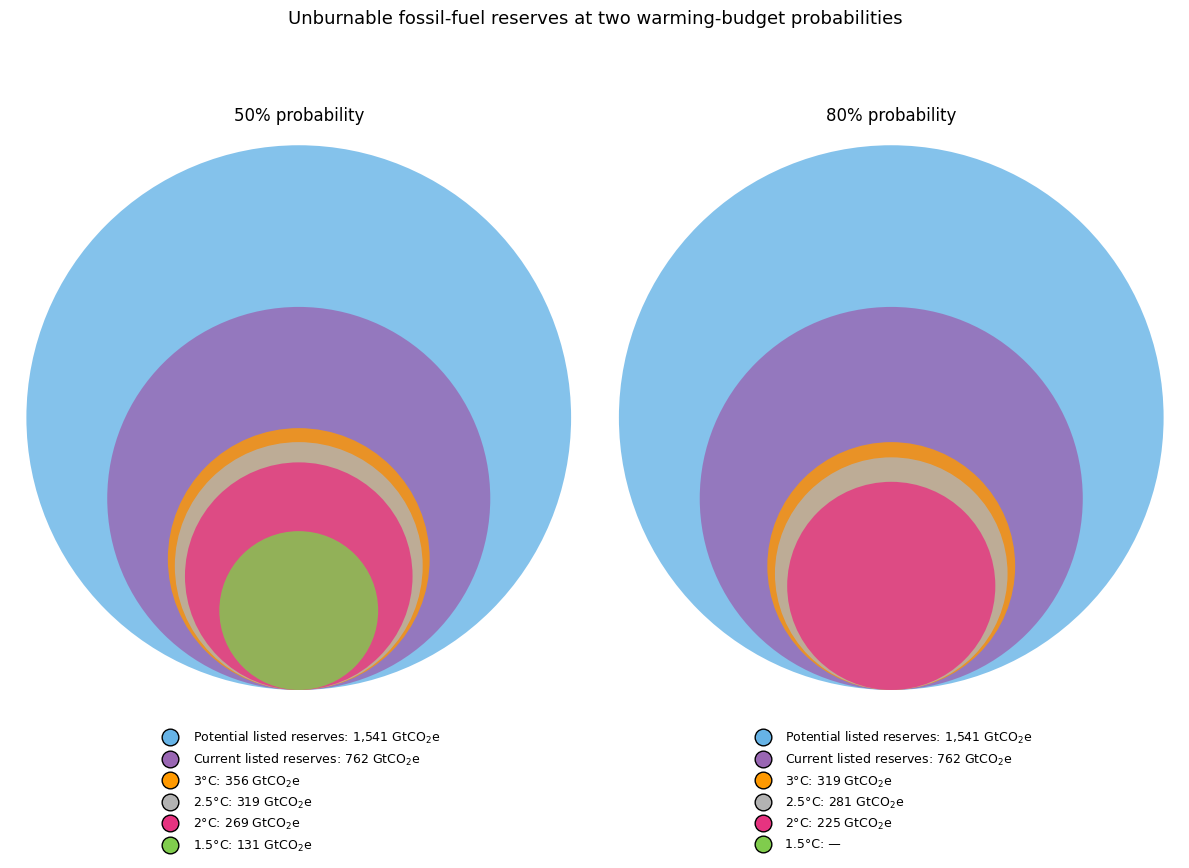

In [2]:
data_50 = [1541, 762, 356, 319, 269, 131]
data_80 = [1541, 762, 319, 281, 225, 0]
colors = [
    (0.4, 0.7, 0.9),   # potential listed reserves
    (0.6, 0.4, 0.7),   # current listed reserves
    (1.0, 0.6, 0.0),   # 3C
    (0.7, 0.7, 0.7),   # 2.5C
    (0.9, 0.2, 0.5),   # 2C
    (0.5, 0.8, 0.3),   # 1.5C
]
temp_labels = ["3\u00b0C", "2.5\u00b0C", "2\u00b0C", "1.5\u00b0C"]
ring_labels = ["Potential listed reserves", "Current listed reserves", *temp_labels]

def carbon_bubble_panel(ax, data, title, r_max):
    radii = 0.15 * np.sqrt(np.array(data) / np.pi)
    y_min = -radii[0]
    for i, (r, c) in enumerate(zip(radii, colors)):
        cy = y_min + r
        ax.add_patch(plt.Circle((0, cy), r, facecolor=c, edgecolor="none", alpha=0.8, zorder=i))
    ax.set_xlim(-r_max - 0.2, r_max + 0.2)
    ax.set_ylim(y_min - 0.2, y_min + 2 * radii[0] + 0.2)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title, fontsize=12)

r_max = 0.15 * np.sqrt(max(data_50[0], data_80[0]) / np.pi)
fig, axes = plt.subplots(1, 2, figsize=(12, 8.5))
carbon_bubble_panel(axes[0], data_50, "50% probability", r_max)
carbon_bubble_panel(axes[1], data_80, "80% probability", r_max)

for ax, data in zip(axes, [data_50, data_80]):
    handles = [plt.Line2D([0], [0], marker="o", color="none", markerfacecolor=c, markersize=12)
               for c in colors]
    labels = [f"{lab}: {val:,} GtCO$_2$e" if val > 0 else f"{lab}: \u2014"
              for lab, val in zip(ring_labels, data)]
    ax.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, -0.02),
              fontsize=9, frameon=False, ncol=1)

fig.suptitle("Unburnable fossil-fuel reserves at two warming-budget probabilities", fontsize=13)
plt.tight_layout()
plt.show()

## 2. A carbon-budget allocation worked example

A simplified illustration of the same "unburnable carbon" logic behind
Section 1, using the widely-cited Carbon Tracker (2011) figures: total
proved fossil-fuel reserves of $x=2795\,\mathrm{GtCO_2}$, split across
three reserve categories with shares $p=(0.65, 0.22, 0.13)$, against a
remaining carbon budget of $y=565\,\mathrm{GtCO_2}$. (The three
categories aren't explicitly named in the underlying figures; based on
the well-known Carbon Tracker reserve shares being reproduced here,
they most plausibly correspond to coal/oil/gas in descending reserve
share — noted as an inference, not a confirmed labeling.)

The allocation logic: the largest category is excluded entirely
($q_1=0$), the smallest is kept at its full share ($q_3=p_3$), and the
middle category absorbs whatever budget remains
($q_2=y/x-q_3$) — illustrating that under a tight carbon budget, only a
fraction of *any* reserve category, and none of the largest, can
actually be burned.

In [3]:
x = 2795  # total proved fossil-fuel reserves (GtCO2), Carbon Tracker (2011)
p = np.array([0.65, 0.22, 0.13])
print(f"Reserve category shares sum to {p.sum():.2f} (should be 1.00)")

y = 565  # remaining carbon budget (GtCO2)
sum_q = y / x
q = np.array([0.00, sum_q - 0.13, 0.13])
print(f"Budget-constrained allocation q = {q.round(4).tolist()}, "
      f"sum(q)*x = {(q.sum()*x):.1f} GtCO2 (should match the {y} GtCO2 budget)")

usable_share = q / p
table = pd.DataFrame({
    "Reserve share p_i": p,
    "Budget-compatible allocation q_i": q,
    "Usable fraction of category (q_i/p_i)": usable_share,
})
table.index = ["Category 1 (largest reserve)", "Category 2 (mid-size reserve)", "Category 3 (smallest reserve)"]
display((100 * table).round(1).rename(columns=lambda c: c + " (%)" if "fraction" not in c.lower() else c))
print(f"\n-> Category 1 is fully stranded (0% usable); Category 2 is ~{100*usable_share[1]:.0f}% usable; "
      f"Category 3 is fully usable (100%) within the {y} GtCO2 budget.")

Reserve category shares sum to 1.00 (should be 1.00)
Budget-constrained allocation q = [0.0, 0.0721, 0.13], sum(q)*x = 565.0 GtCO2 (should match the 565 GtCO2 budget)


,Reserve share p_i (%),Budget-compatible allocation q_i (%),Usable fraction of category (q_i/p_i)
Category 1 (largest reserve),65.0,0.0,0.0
Category 2 (mid-size reserve),22.0,7.2,32.8
Category 3 (smallest reserve),13.0,13.0,100.0



-> Category 1 is fully stranded (0% usable); Category 2 is ~33% usable; Category 3 is fully usable (100%) within the 565 GtCO2 budget.


## 3. Stranded-asset valuation under baseline vs. climate scenarios

A full worked stranded-asset valuation model on illustrative production
data (`chap10_stranded_data2.xlsx`): a fixed total resource stock
$Q_0=4$ billion barrels, split each year between a **baseline**
(business-as-usual) and a **climate** (transition) scenario, each with
its own production share, price, and marginal-cost path. Stranded
volume is the cumulative production shortfall between scenarios;
stranded *value* is the present value of forgone producer surplus
(price minus marginal cost, times volume) plus forgone carbon-related
costs, discounted at four illustrative rates.

In [4]:
T = pd.read_excel(f"{DATA_DIR}/chap10_stranded_data2.xlsx", sheet_name="Example")
Q0 = 4.0e9  # barrels

t = T["Year"].values
t0 = t[0]
q1, P1, MC1, C1 = T["Share_Baseline"].values, T["Price_Baseline"].values, T["MC_Baseline"].values, T["CE_Baseline"].values * 1e6
q2, P2, MC2, C2 = T["Share_Climate"].values, T["Price_Climate"].values, T["MC_Climate"].values, T["CE_Climate"].values * 1e6

display(pd.DataFrame({
    "Year": t, "Price (baseline)": P1, "MC (baseline)": MC1, "Share % (baseline)": 100 * q1,
    "Price (climate)": P2, "MC (climate)": MC2, "Share % (climate)": 100 * q2,
}).round(2))

Q1, Q2 = Q0 * q1, Q0 * q2
SA_barrels = np.sum(Q1 - Q2)
SA_CO2 = SA_barrels * 0.430  # tCO2 per barrel, illustrative conversion factor
print(f"Cumulative stranded volume: {SA_barrels/1e6:,.1f} million barrels "
      f"({SA_CO2/1e6:,.1f} million tCO2 avoided)")

varrho = np.array([0.00, 0.03, 0.05, 0.10])
DF = 1 / (1 + varrho[:, None]) ** (t - t0)  # shape (4 rates, n years)
VR1 = ((P1 - MC1) * Q1 - C1) * DF
VR2 = ((P2 - MC2) * Q2 - C2) * DF
VC1 = C1 * DF
VC2 = C2 * DF

per_year = pd.DataFrame({
    "Year": t, "Q1 (baseline, m barrels)": Q1 / 1e6, "Q2 (climate, m barrels)": Q2 / 1e6,
    "VR1 ($m, d=3%)": VR1[1] / 1e6, "VR2 ($m, d=3%)": VR2[1] / 1e6,
    "Delta VR ($m, d=3%)": (VR1[1] - VR2[1]) / 1e6, "Delta VC ($m, d=3%)": (VC1[1] - VC2[1]) / 1e6,
})
display(per_year.round(2))

SR = np.sum(VR1 - VR2, axis=1)
SC = np.sum(VC1 - VC2, axis=1)
SA = SR + SC
summary = pd.DataFrame({
    "Discount rate": varrho,
    "PV producer surplus, baseline ($bn)": np.sum(VR1, axis=1) / 1e9,
    "PV producer surplus, climate ($bn)": np.sum(VR2, axis=1) / 1e9,
    "Stranded revenue, SR ($bn)": SR / 1e9,
    "PV carbon cost, baseline ($bn)": np.sum(VC1, axis=1) / 1e9,
    "PV carbon cost, climate ($bn)": np.sum(VC2, axis=1) / 1e9,
    "Stranded cost, SC ($bn)": SC / 1e9,
    "Total stranded value, SA ($bn)": SA / 1e9,
})
display(summary.round(2))

,Year,Price (baseline),MC (baseline),Share % (baseline),Price (climate),MC (climate),Share % (climate)
0,2025,60,30,5.0,60,30.0,5.00
1,2026,60,30,5.0,59,30.5,4.75
2,2027,60,30,5.0,58,31.0,4.50
3,2028,60,30,5.0,57,31.5,4.25
4,2029,60,30,5.0,56,32.0,4.00
5,2030,60,30,5.0,55,32.5,3.75
6,2031,60,30,5.0,54,33.0,3.50
7,2032,60,30,5.0,53,33.5,3.25
8,2033,60,30,5.0,52,34.0,3.00
9,2034,60,30,5.0,51,34.5,2.75


Cumulative stranded volume: 1,200.0 million barrels (516.0 million tCO2 avoided)


,Year,"Q1 (baseline, m barrels)","Q2 (climate, m barrels)","VR1 ($m, d=3%)","VR2 ($m, d=3%)","Delta VR ($m, d=3%)","Delta VC ($m, d=3%)"
0,2025,200.0,200.0,5000.00,5000.00,0.00,0.00
1,2026,200.0,190.0,4854.37,4334.95,519.42,48.54
2,2027,200.0,180.0,4712.98,3732.68,980.30,94.26
3,2028,200.0,170.0,4575.71,3189.27,1386.44,137.27
4,2029,200.0,160.0,4442.44,2701.00,1741.43,177.70
5,2030,200.0,150.0,4313.04,2264.35,2048.70,215.65
6,2031,200.0,140.0,4187.42,1875.96,2311.46,251.25
7,2032,200.0,130.0,4065.46,1532.68,2532.78,284.58
8,2033,200.0,120.0,3947.05,1231.48,2715.57,315.76
9,2034,200.0,110.0,3832.08,969.52,2862.57,344.89


,Discount rate,"PV producer surplus, baseline ($bn)","PV producer surplus, climate ($bn)","Stranded revenue, SR ($bn)","PV carbon cost, baseline ($bn)","PV carbon cost, climate ($bn)","Stranded cost, SC ($bn)","Total stranded value, SA ($bn)"
0,0.00,80.00,32.60,47.40,16.00,10.00,6.00,53.40
1,0.03,64.69,29.02,35.67,12.94,8.49,4.45,40.11
2,0.05,56.90,27.05,29.84,11.38,7.70,3.68,33.53
3,0.10,43.03,23.19,19.84,8.61,6.22,2.39,22.23


## 4. Hansen-style stranded-value table by fuel type

Of the four Hansen-sourced scenario sheets available in
`chap10_stranded_data3.xlsx` (`Table 9a/9b`, `Table 10a/10b`), this
section uses only the two "a" variants (`Table 9a`, `Table 10a`), and
within each, drops the "Oil" row, keeping only Gas, Coal, and Total.
For each kept row it shows the value at 5 discount rates ($bn,
dividing the raw \$m figures by 1000) alongside that row's value as a
percentage of the same table's "Total" row at each discount rate (with
the Total row's own percentage column blanked, since it would
trivially read 100%). What distinguishes "9" from "10" or "a" from "b"
isn't documented beyond the "Hansen" sheet-name citation, so this
section reproduces the table's mechanics without inventing a scenario
interpretation that isn't stated.

In [5]:
def hansen_pct_of_total(sheet_name):
    T = pd.read_excel(f"{DATA_DIR}/chap10_stranded_data3.xlsx", sheet_name=sheet_name)
    T = T.set_index("d")
    data = T.iloc[1:] / 1e3  # drop the "Oil" row, convert $m -> $bn
    pct_of_total = 100 * data / data.iloc[-1]  # each row as % of the Total row, per column
    pct_of_total.iloc[-1] = np.nan  # blank the Total row's own (trivial 100%) percentages
    pct_of_total.columns = [f"{c} (% of total)" for c in pct_of_total.columns]
    combined = pd.concat([data, pct_of_total], axis=1)
    combined.index = [f"{i} ({sheet_name})" for i in combined.index]
    return combined

table_9a = hansen_pct_of_total("Table 9a - Hansen")
table_10a = hansen_pct_of_total("Table 10a - Hansen")
results = pd.concat([table_9a, table_10a])
display(results.round(2))

,0,0.03,0.05,0.08,0.1,0 (% of total),0.03 (% of total),0.05 (% of total),0.08 (% of total),0.1 (% of total)
Gas (Table 9a - Hansen),3.91,2.98,2.51,1.98,1.71,12.57,12.85,13.00,13.17,13.25
Coal (Table 9a - Hansen),3.76,2.60,2.08,1.52,1.26,12.07,11.23,10.75,10.12,9.76
Total (Table 9a - Hansen),31.14,23.17,19.33,15.04,12.89,NaN,NaN,NaN,NaN,NaN
Gas (Table 10a - Hansen),8.37,6.45,5.49,4.38,3.81,20.64,21.17,21.49,21.89,22.11
Coal (Table 10a - Hansen),5.07,3.56,2.87,2.13,1.78,12.49,11.71,11.25,10.65,10.32
Total (Table 10a - Hansen),40.56,30.45,25.54,20.02,17.23,NaN,NaN,NaN,NaN,NaN
